https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-03.K-%EC%B5%9C%EA%B7%BC%EC%A0%91-%EC%9D%B4%EC%9B%83KNN

train shape: (120, 4)
test shape: (30, 4)
   k  accuracy
0  1       1.0
1  3       1.0
2  5       1.0
3  7       1.0
4  9       1.0


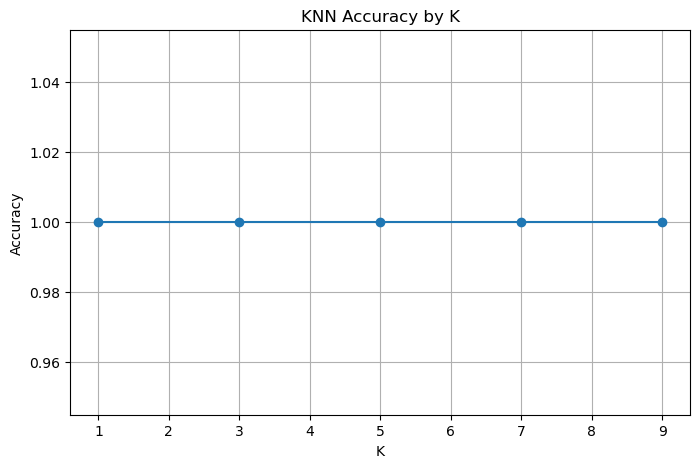


최적 K = 1

Accuracy: 1.0

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 모델
from sklearn.neighbors import KNeighborsClassifier

# 데이터
from sklearn.datasets import load_iris

# 분할
from sklearn.model_selection import train_test_split

# 스케일링
from sklearn.preprocessing import StandardScaler

# 평가
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==============================
# 1. 데이터 로드
# ==============================
iris = load_iris()

X = iris.data
y = iris.target


# ==============================
# 2. 데이터 분할
# ==============================
train_x, test_x, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ==============================
# 3. 스케일링
# ==============================
scaler = StandardScaler()

train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

print("train shape:", train_x.shape)
print("test shape:", test_x.shape)


# ==============================
# 4. k 값 비교
# ==============================
k_list = [1, 3, 5, 7, 9]

results = []

for k in k_list:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    # 학습
    model.fit(train_x, train_y)

    # 예측
    pred = model.predict(test_x)

    # 평가
    acc = accuracy_score(test_y, pred)

    results.append([k, acc])


# ==============================
# 5. 결과 출력
# ==============================
result_df = pd.DataFrame(
    results,
    columns=["k", "accuracy"]
)

print(result_df)


# ==============================
# 6. 시각화
# ==============================
plt.figure(figsize=(8, 5))

plt.plot(
    result_df["k"],
    result_df["accuracy"],
    marker="o"
)

plt.title("KNN Accuracy by K")
plt.xlabel("K")
plt.ylabel("Accuracy")

plt.grid()

plt.show()


# ==============================
# 7. 최적 K 선택
# ==============================
best_k = result_df.loc[
    result_df["accuracy"].idxmax(),
    "k"
]

print("\n최적 K =", best_k)


# ==============================
# 8. 최종 모델
# ==============================
best_model = KNeighborsClassifier(
    n_neighbors=int(best_k)
)

best_model.fit(
    train_x,
    train_y
)

final_pred = best_model.predict(
    test_x
)


# ==============================
# 9. 최종 평가
# ==============================
print(
    "\nAccuracy:",
    accuracy_score(
        test_y,
        final_pred
    )
)

print(
    "\nConfusion Matrix"
)

print(
    confusion_matrix(
        test_y,
        final_pred
    )
)

print(
    "\nClassification Report"
)

print(
    classification_report(
        test_y,
        final_pred
    )
)